# T-Test for Same vs. Different Operating and Ticket Carriers

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
q3_2024 = pd.read_csv('../../data/2024_q3.csv')
q4_2024 = pd.read_csv('../../data/2024_q4.csv')
q1_2025 = pd.read_csv('../../data/2025_q1.csv')
q2_2025 = pd.read_csv('../../data/2025_q2.csv')

In [3]:
df = pd.concat([q3_2024, q4_2024, q1_2025, q2_2025], ignore_index=True)


In [4]:
df = df[df['REPORTING_CARRIER'] != '99']
df = df[df['TICKET_CARRIER'] != '99']
df = df[df['OPERATING_CARRIER'] != '99']

In [5]:
df.shape

(27378923, 15)

In [6]:
same_carrier = df['TICKET_CARRIER'] == df['OPERATING_CARRIER']

# Count how many are the same
num_same = same_carrier.sum()

# Total rows
total = len(df)

# Percentage of matches
pct_same = num_same / total * 100

print(f"Same carrier count: {num_same:,}")
print(f"Total rows: {total:,}")
print(f"Percentage same: {pct_same:.2f}%")

Same carrier count: 23,609,712
Total rows: 27,378,923
Percentage same: 86.23%


In [ ]:
same_carrier_df = df[same_carrier]
different_carrier_df = df[~same_carrier]

print(same_carrier_df.shape)
print(different_carrier_df.shape)

(23609712, 15)
(3769211, 15)


In [8]:
same_carrier_df.columns

Index(['YEAR', 'QUARTER', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID',
       'DEST', 'REPORTING_CARRIER', 'TICKET_CARRIER', 'OPERATING_CARRIER',
       'BULK_FARE', 'PASSENGERS', 'MARKET_FARE', 'MARKET_DISTANCE',
       'NONSTOP_MILES', 'MKT_GEO_TYPE'],
      dtype='object')

In [10]:
same_carrier_df = same_carrier_df.loc[:, ['TICKET_CARRIER', 'OPERATING_CARRIER', 'MARKET_FARE']]

In [11]:
different_carrier_df = different_carrier_df.loc[:, ['TICKET_CARRIER', 'OPERATING_CARRIER', 'MARKET_FARE']]

In [12]:
same_carrier_df.columns

Index(['TICKET_CARRIER', 'OPERATING_CARRIER', 'MARKET_FARE'], dtype='object')

In [15]:
from scipy import stats

In [ ]:
col1 = same_carrier_df['MARKET_FARE'].dropna()
col2 = different_carrier_df['MARKET_FARE'].dropna()

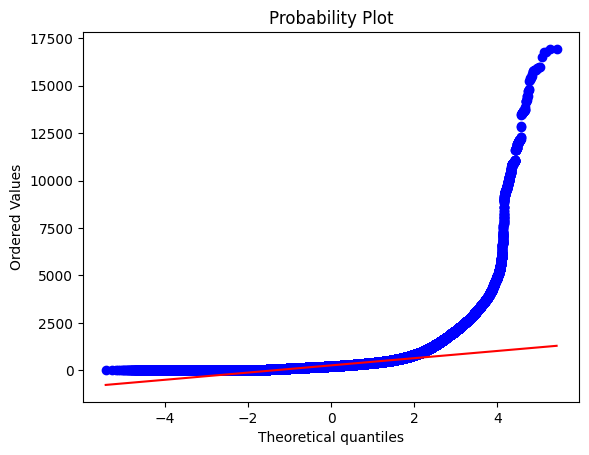

In [17]:
stats.probplot(col1, dist="norm", plot=plt)
plt.show()

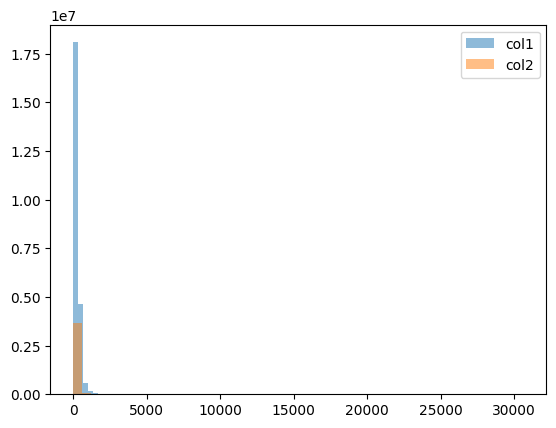

In [ ]:
plt.hist(col1, bins=50, alpha=0.5, label='col1')
plt.hist(col2, bins=50, alpha=0.5, label='col2')
plt.legend()
plt.show()

In [18]:


# Replace with your actual data sources

# Mann–Whitney U test
stat, p_value = stats.mannwhitneyu(col1, col2, alternative='two-sided')

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 42854243996630.5
p-value: 0.0
